<a href="https://colab.research.google.com/github/d-tom75/avian-phylogeny-project/blob/main/cs466_project_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hierarchical Clustering Implementation

##Imports and Installs

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.4 MB/s eta 0:00:00


In [2]:
!pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 27.3 MB/s eta 0:00:00


In [3]:
!pip install git+https://github.com/koonimaru/radialtree

  Cloning https://github.com/koonimaru/radialtree to /tmp/pip-req-build-pkh1kyip
  Running command git clone --filter=blob:none --quiet https://github.com/koonimaru/radialtree /tmp/pip-req-build-pkh1kyip
  Resolved https://github.com/koonimaru/radialtree to commit e5b40b695b9d800838102d1a8af74584fc20ff40
  Preparing metadata (setup.py) ... done
  Created wheel for radialtree: filename=radialtree-0.1.0-py3-none-any.whl size=19055 sha256=e6f29ada4b9f1dce39e3a2d01baa92ff79bb27dcdaa74e216b3f1de09a9a1acd
  Stored in directory: /tmp/pip-ephem-wheel-cache-oj197md_/wheels/63/8f/4a/9544781e1038ca932e45826efd0747ef4c0ced9a5203e204b9
Successfully built radialtree


In [27]:
!pip install pymsaviz -q

In [4]:
# Install Clustal Omega, a multiple sequence alignment program
!apt-get install clustalo

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libargtable2-0
The following NEW packages will be installed:
  clustalo libargtable2-0
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 273 kB of archives.
After this operation, 694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libargtable2-0 amd64 13-1.1 [14.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 clustalo amd64 1.2.4-7 [259 kB]
Fetched 273 kB in 0s (1,018 kB/s)
Selecting previously unselected package libargtable2-0.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .../clustalo_1.2.4-7_amd64.deb ...
Unpacking clustalo (1.2.4-7) ...
Setting u

In [28]:
import subprocess
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import logomaker as lm
import radialtree as rt
from Bio import SeqIO
from Bio import AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
from Bio.Phylo.TreeConstruction import DistanceCalculator
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram
from pymsaviz import MsaViz

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [6]:
if os.path.exists("/content/avian-phylogeny-project"):
  print("Already cloned")
else:
  subprocess.run(["git", "clone",
    "https://github.com/d-tom75/avian-phylogeny-project.git"], check=True)

##Data Preprocessing

In [7]:
# returns a dict where species_seq[species name] --> nucleutide sequence . species_seq[str] --> str
def extractFromData(data_path):
  data_dir = Path(data_path)
  all_records = []
  species_data = {}
  species_seq = {}
  firstN = 30
  i = 0
  for species_dir in sorted(data_dir.iterdir()):
    if firstN > 0 and i == firstN:
      break
    i += 1
    gene_file = species_dir / 'ncbi_dataset' / 'data' / 'gene.fna'
    split_species = str(species_dir).split('/')
    species_array = split_species[len(split_species) - 1].split("_")
    if gene_file.exists():
      for record in SeqIO.parse(str(gene_file), 'fasta'):
        species_name = species_array[0] + " " + species_array[1]
        species_seq[species_name] = record.seq
  return species_seq

In [8]:
# takes in an array of strings and returns the multiple sequence alignment in the form of a "MultipleSeqAlignment" object
def createMSA(species_seq):
  sequences = []
  for species, seq in species_seq.items():
    clean_id = species.replace(" ", "_")
    sequences.append(SeqRecord(Seq(seq), id=clean_id))

  input_file = "input_sequences.fasta"
  output_file = "aligned_sequences.fasta"

  SeqIO.write(sequences, input_file, "fasta")

  command = [
      "clustalo",
      "-i", input_file,
      "-o", output_file,
      "--outfmt=fa",
      "--threads=2",
      "-v"
  ]

  try:
    result = subprocess.run(command, capture_output=True, text=True, check=True)
  except subprocess.CalledProcessError as e:
      print(f"Error running Clustal Omega: {e.stderr}")

  alignment = SeqIO.parse(output_file, "fasta")

  msa = []
  for record in alignment:
      msa.append(record)
  msa = MultipleSeqAlignment(msa)

  os.remove(input_file)
  os.remove(output_file)

  return msa

In [9]:
# takes in a multiple sequence alignment object and returns a tuple of the names of the ids and their respectictive dist matrix
def computeDistMatK80(msa):
  names = [line.id for line in msa]
  msa_list = [[nuc for nuc in line.seq] for line in msa]
  num_sequences = len(msa_list)
  dist_matrix = [[0 for i in range(num_sequences)] for i in range(num_sequences)]
  for seq_1 in range(num_sequences - 1):
    for seq_2 in range(seq_1 + 1, num_sequences):
      p = 0
      q = 0
      total = 0
      for index in range(len(msa_list[seq_1])):
        pair = set()
        pair.add(msa_list[seq_1][index])
        pair.add(msa_list[seq_2][index])
        if '-' not in pair:
          total += 1
          if (msa_list[seq_1][index] != msa_list[seq_2][index]):
            if ('A' in pair and 'G' in pair) or ('T' in pair and 'C' in pair):
              p += 1
            else:
              q += 1
      if total == 0:
        dist = 0
      else:
        p /= total
        q /= total
        l1 = 1 - (2 * p) - q
        l2 = 1 - (2 * q)
        if l1 < 0 or l2 < 0:
          dist = float('inf')
        else:
          dist = (-(1 / 2) * math.log(l1)) - ((1 / 4) * math.log(l2))
      dist_matrix[seq_1][seq_2] = dist
      dist_matrix[seq_2][seq_1] = dist

  return (names, dist_matrix)

In [10]:
def naiveClosestIndices(dist_matrix, indicesInPlay):
  minVal = np.inf
  clust1 = 0
  clust2 = 0
  listIndices  = list(indicesInPlay)
  for i in listIndices:
    for j in listIndices:
      if i == j:
        continue
      if minVal > dist_matrix[i][j]:
        clust1 = i
        clust2 = j
        minVal = dist_matrix[i][j]
  return (clust1, clust2, minVal)

In [11]:
# the tree that is returned is a dictionary
# where tree[node value] --> none if leaf,
# else tuple as such ((child left, child right), distance between child clusters, amount of nodes the supercluster constains).
def hierchClust(dist_matrix):
  dist_matrix = np.array(dist_matrix, dtype=float)

  nextClustVal = len(dist_matrix)
  indicesInPlay = set([i for i in range(nextClustVal)])
  counts = {i: 1 for i in range(nextClustVal)}
  tree = {}
  for i in range(nextClustVal):
    tree[i] = None

  while len(indicesInPlay) > 1:
    clust1, clust2, val = naiveClosestIndices(dist_matrix, indicesInPlay)
    counts[nextClustVal] = counts[clust1] + counts[clust2]
    tree[nextClustVal] = ((clust1, clust2), val, counts[nextClustVal])

    dist_matrix = np.append(dist_matrix, [np.zeros_like(dist_matrix[0])], axis=0)
    dist_matrix = np.append(dist_matrix, np.zeros((dist_matrix.shape[0], 1)), axis=1)
    indicesInPlay.remove(clust1)
    indicesInPlay.remove(clust2)
    for idx in indicesInPlay:
      val = .5 * (dist_matrix[idx, clust1] + dist_matrix[idx, clust2])
      dist_matrix[nextClustVal, idx] = dist_matrix[idx, nextClustVal] = val

    indicesInPlay.add(nextClustVal)
    nextClustVal += 1
  root = nextClustVal - 1
  return (tree, root)

In [12]:
def assembleTree(tree, root, names):
    linkageMatrix = []

    firstInternal = len(names)

    for i in range(firstInternal, root + 1):
        (clust1, clust2), dist, size = tree[i]
        print((clust1, clust2), size)
        linkageMatrix.append([clust1, clust2, dist, size])

    plt.figure(figsize=(15, 8))
    tree = dendrogram(
        linkageMatrix,
        labels=names,
        leaf_rotation=45,
        leaf_font_size=10,
        distance_sort='descending',
        show_leaf_counts=True
    )
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Species")
    plt.ylabel("Distance")
    plt.show()
    return tree

##Sanity check code on example data

In [13]:
# Create some example sequences
sequences = [
    SeqRecord(Seq("GCACTGGCTCGA"), id="seq1"),
    SeqRecord(Seq("GCCATAGCTTGA"), id="seq2"),
    SeqRecord(Seq("GCATAGGACTGA"), id="seq3"),
    SeqRecord(Seq("GCATAGGCTGA"), id="seq4"), # Shorter sequence
]

# Write sequences to a temporary FASTA file
input_file = "input_sequences.fasta"
output_file = "aligned_sequences.fasta"
SeqIO.write(sequences, input_file, "fasta")

command = [
    "clustalo",
    "-i", input_file,
    "-o", output_file,
    "--outfmt=fa",
    "--auto",
    "-v"
]

# Execute using subprocess
print("Running Clustal Omega...")
try:
    result = subprocess.run(command, capture_output=True, text=True, check=True)
    print("Clustal Omega output:\n", result.stdout)
except subprocess.CalledProcessError as e:
    print(f"Error running Clustal Omega: {e.stderr}")

# Read and print the alignment
print("\nMultiple Sequence Alignment Result:")
alignment = SeqIO.parse(output_file, "fasta")
msa = []
for record in alignment:
    msa.append(record)
    print(f"{record.id}: {record.seq}")
msa = MultipleSeqAlignment(msa)

# Clean up temporary files
os.remove(input_file)
os.remove(output_file)
print(msa)

Running Clustal Omega...
Clustal Omega output:
 Using 2 threads
Read 4 sequences (type: DNA) from input_sequences.fasta
not more sequences (4) than cluster-size (100), turn off mBed
Setting options automatically based on input sequence characteristics (might overwrite some of your options).
Auto settings: Enabling mBed.
Auto settings: Setting iteration to 1.
Using 3 seeds (chosen with constant stride from length sorted seqs) for mBed (from a total of 4 sequences)
Calculating pairwise ktuple-distances...
Ktuple-distance calculation progress: 0 % (0 out of 9)
Ktuple-distance calculation progress: 22 % (2 out of 9)
Ktuple-distance calculation progress: 33 % (3 out of 9)
Ktuple-distance calculation progress done. CPU time: 0.00u 0.00s 00:00:00.00 Elapsed: 00:00:00
mBed created 1 cluster/s (with a minimum of 1 and a soft maximum of 100 sequences each)
Distance calculation within sub-clusters: 0 % (0 out of 1)
Distance calculation within sub-clusters done. CPU time: 0.00u 0.00s 00:00:00.00 E

In [14]:
calculator = DistanceCalculator('identity')
dm = calculator.get_distance(msa)

In [15]:
dm

DistanceMatrix(names=['seq1', 'seq2', 'seq3', 'seq4'], matrix=[[0], [0.33333333333333337, 0], [0.41666666666666663, 0.5, 0], [0.6666666666666667, 0.33333333333333337, 0.5833333333333333, 0]])

In [16]:
test_4x4 = [
    [0.0, 0.10, 0.40, 0.40],
    [0.10, 0.0, 0.35, 0.35],
    [0.40, 0.35, 0.0, 0.15],
    [0.40, 0.35, 0.15, 0.0]
]

tree, root = hierchClust(test_4x4)
print("root", root)
print("Final Tree Structure:", tree)

root 6
Final Tree Structure: {0: None, 1: None, 2: None, 3: None, 4: ((0, 1), np.float64(0.1), 2), 5: ((2, 3), np.float64(0.15), 2), 6: ((4, 5), np.float64(0.375), 4)}


(0, 1) 2
(2, 3) 2
(4, 5) 4


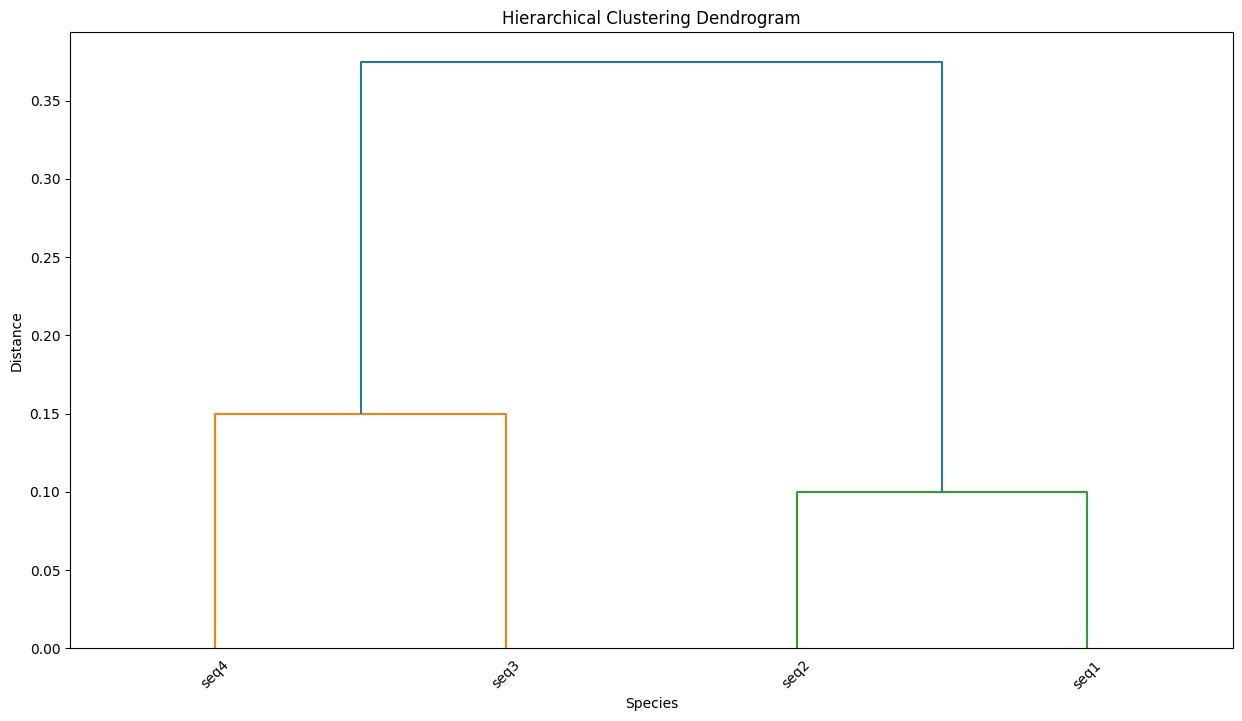

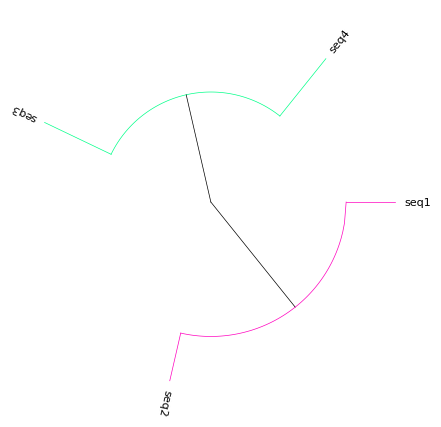

In [17]:
tree = assembleTree(tree, root, ['seq1', 'seq2', 'seq3', 'seq4'])
rt.plot(tree)

##Run code on RAG1 data

In [18]:
def computePhylogenyFromData(data_path):
  species_seq = extractFromData(data_path)
  print("finished extracting...", species_seq)
  msa = createMSA(species_seq)
  print("created msa...", msa)
  names, dist_matrix = computeDistMatK80(msa)
  print("computed distance matrix...", names, dist_matrix)
  tree, root = hierchClust(dist_matrix)
  print("computed phylogeny...", tree, root)
  assembled_tree = assembleTree(tree, root, names)
  print("tree assembled...")
  return msa, assembled_tree

finished extracting... {'Anas platyrhynchos': Seq('CTTCCTTCTCTTTCTTAGGTGATTTGGTTTCTGACACACTGGAGATGTCGATAG...TTT'), 'Aphelocoma coerulescens': Seq('ATGGAATTATTATTACTTTTGGAAAATTAGCTAACTTACTTATCTATCTTTCTA...TAA'), 'Aptenodytes forsteri': Seq('ATGTCAGTAGCATCACAAATGGACCTGCCTGAAGAAATTCAGCACCCATATACA...TAA'), 'Apteryx mantelli': Seq('ATGTCAGTAGCATCAAAAATGGACCTGCCTGAAGAAATTCAGCATCCATTTACA...GGT'), 'Apteryx rowi': Seq('TTGGCTGTTTGTATCGGTGAGCTTTCTTGGCAGCAGTCTCGCGCTAACGTGTCT...TAA'), 'Athene cunicularia': Seq('ATGGCATTATTATTAATTTTGGAAGATAAGCTAACTTAGAGCTTCTTTCTCTTT...TAA'), 'Balearica regulorum': Seq('AGATGGTTCTTCTGGAAGGTTCCTTGGCACTGTGGGCATTCCACAGTGGAAAAA...TAG'), 'Calonectris borealis': Seq('ATGGCGTTATTAATTTTGGAAGATAAGCTAACTCACAGCTTCTTTCTGTTTCTC...TAA'), 'Cariama cristata': Seq('ATGTCAGGAGCATCACAAATGGACCTGCCTGAAGAAATTCAGCATCCGTATACA...TAA'), 'Catharus ustulatus': Seq('ATGCCGGTAGCATCACAGATGGACCTACCTGAAGAACTTCAGCATACATATACA...TAA'), 'Columba livia': Seq('TGGACAGTCATGTCTGGGCCTCTCAATTCAGTAAGCATCTTGGA

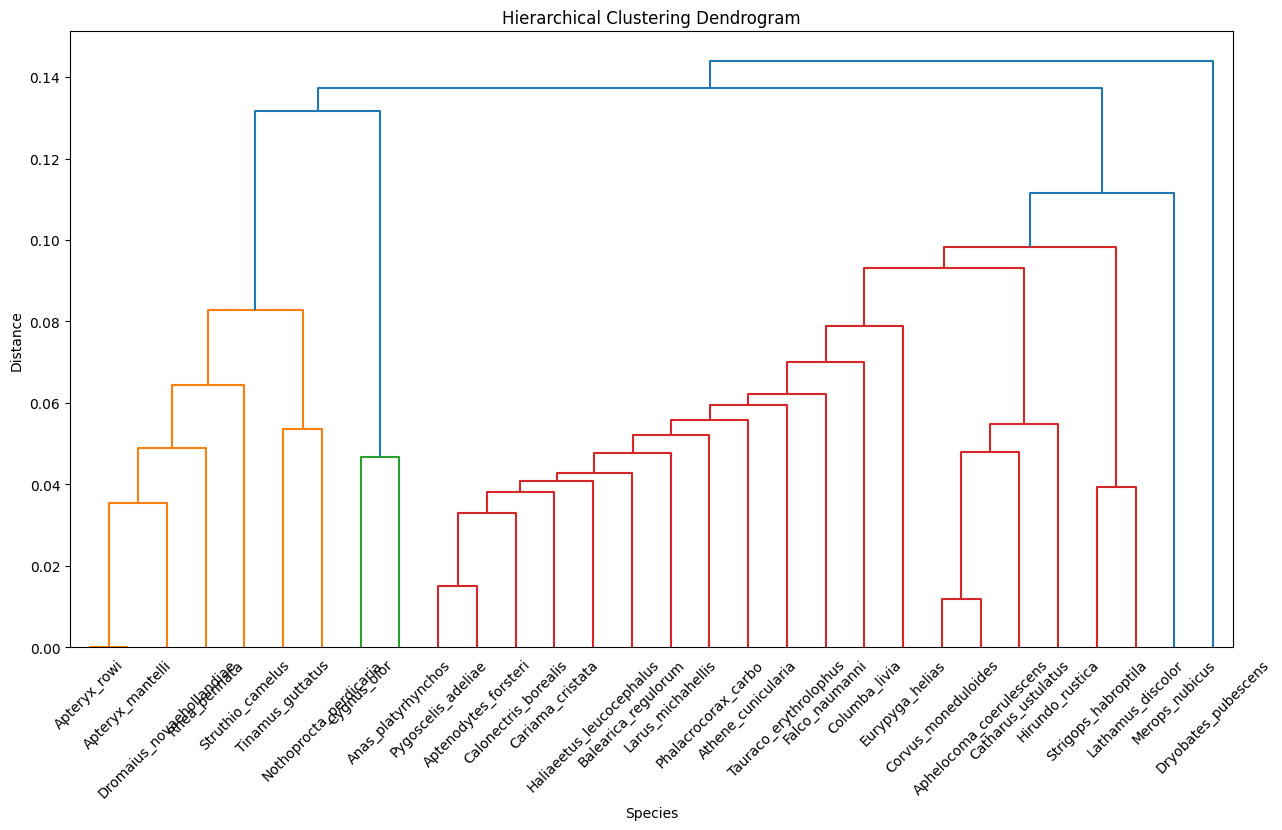

tree assembled...


In [19]:
msa, assembled_tree = computePhylogenyFromData("/content/avian-phylogeny-project/data")

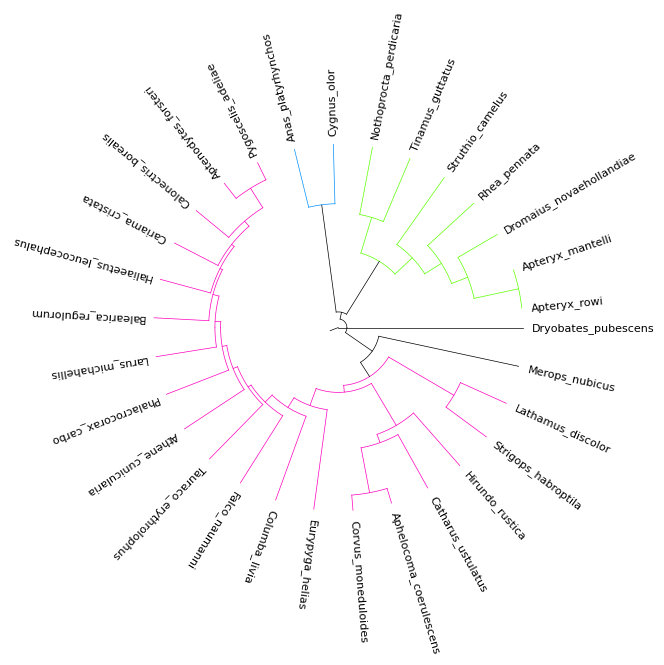

In [20]:
rt.plot(assembled_tree)

##Visualize MSA

In [21]:
AlignIO.write(msa, "output_msa.fasta", "fasta")

1

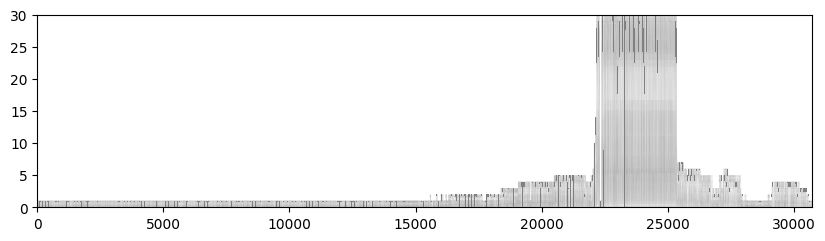

In [22]:
alignment = AlignIO.read("output_msa.fasta", "fasta")
sequences = [str(record.seq) for record in alignment]
counts_mat = lm.alignment_to_matrix(sequences, characters_to_ignore='-')
logo = lm.Logo(counts_mat, stack_order='small_on_top')

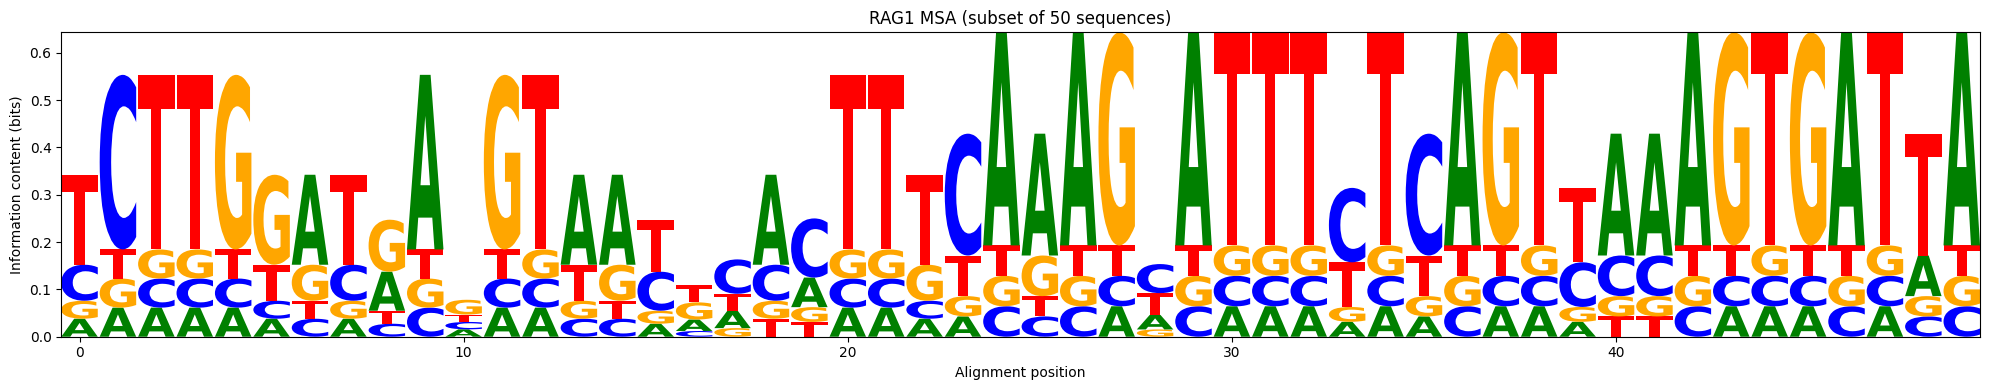

In [26]:
sequences_short = []
for record in SeqIO.parse("output_msa.fasta", "fasta"):
  sequences_short.append(str(record.seq[22000:22050]))
counts_mat_short = lm.alignment_to_matrix(sequences_short, characters_to_ignore='-')
info_mat = lm.transform_matrix(counts_mat_short, from_type='counts', to_type='information')

fig, ax = plt.subplots(figsize=(20, 4))
logo = lm.Logo(info_mat, ax=ax, color_scheme='classic')
ax.set_xlabel("Alignment position")
ax.set_ylabel("Information content (bits)")
ax.set_title("RAG1 MSA (subset of 50 sequences)")
plt.tight_layout()
plt.show()

In [33]:
mv = MsaViz("output_msa.fasta", color_scheme="Nucleotide", start=22050, end=22100,
            show_consensus=True, show_count=True)
mv.savefig("msa_viz.png")